# **Projet Tb3 - Classification automatique des lésions de la peau**

**Auteur :** Raphaël TRINQUANT

**Date :** Décembre 2025

**Résumé :** L'objectif de ce projet est de fournir un outil d'aide à la détéction des mélanomes par la reconnaissance d'image et le machine learning. On utilise un jeu de 200 images étiquetées ainsi que les segmentations binaires et les images superpixélisées correspondantes.

**Méthodologie :**
 - Chargement des images
 - Extractions des features + Analyse exploratoire et nettoyage
 - Modélisation / Analyses des performances et comparatifs des méthodes régréssion logistique / forêt aléatoire / SVM

**Note d'utilisation :** Pour que le code fonctionne, le fichier ipynb doit être dans le même dossier contenant le fichier csv et le dossier des images. De plus, les modules utilisées doivent être installés


## 1. Préparation des données 

### 1.1 Chargement des images

In [1]:
# importer les packages nécéssaires
import cv2 as cv
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from skimage import measure
from skimage.feature import graycomatrix, graycoprops
from skimage.color import rgb2gray
import glob
import os
from tqdm import tqdm

In [2]:
# Charger les images (env 1 min)

# Chemins avec le pattern 
chemin_or = "PROJECT_Data/*.jpg"
chemin_seg = "PROJECT_Data/*segmentation.png"
# chemin_sup = "PROJECT_Data/*superpixels.png"

images_originales = []
images_segmentees = []
# images_superpixels = []

index = []
fichiers_or = glob.glob(chemin_or)
fichiers_seg = glob.glob(chemin_seg)
# fichiers_sup = glob.glob(chemin_sup)

for i in tqdm(range(len(fichiers_or))):
    # cv.imread charge l'image en format BGR (Bleu-Vert-Rouge)
    fichier_or = fichiers_or[i]
    fichier_seg = fichiers_seg[i]
    # fichier_sup = fichiers_sup[i]
    
    index.append(int(str(fichier_or)[22:25]))
    img_or = cv.imread(fichier_or)
    img_seg = cv.imread(fichier_seg)
    # img_sup = cv.imread(fichier_sup)

    if img_or is not None:
        images_originales.append(img_or/255)
    else:
        print(f"Impossible de lire : {fichier_or}")
    
    if img_seg is not None:
        images_segmentees.append(img_seg[:,:,0]//255)
    else:
        print(f"Impossible de lire : {fichier_seg}")
"""
    if img_sup is not None:
        images_superpixels.append(img_sup/255)
    else:
        print(f"Impossible de lire : {fichier_seg}")
"""    
   

print(f"{len(images_originales)} images originales chargées en format tableaux NumPy.")
print(f"{len(images_segmentees)} images chargées segmentées en format tableaux NumPy.")
# print(f"{len(images_superpixels)} images chargées superpixélisées en format tableaux NumPy.")

100%|██████████| 200/200 [00:39<00:00,  5.01it/s]


200 images originales chargées en format tableaux NumPy.
200 images chargées segmentées en format tableaux NumPy.


### 1.2 Extraction des features

In [3]:
# Préparation de la dataframe

df = pd.read_csv("ISIC-2017_Data_GroundTruth_Classification.csv")[:422]
df.drop(columns=['seborrheic_keratosis'], inplace=True)
df['image_id'] = df['image_id'].str[5:].astype(int)
df = df[df['image_id'].isin(index)]

parametres = ['area', 'perimeter', 'equiv_diameter', 'major_axis', 
              'minor_axis', 'eccentricity', 'solidity', 'extent', 'circularity', 'aspect_ratio', 
              'blue_mean', 'green_mean', 'red_mean', 'blue_std', 'green_std', 'red_std', 
              'hue_mean', 'saturation_mean', 'value_mean', 
              'contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation']
for col in parametres:
    df[col]=np.nan


df.set_index('image_id', inplace=True)


In [4]:
# Extraction des caractéristiques géométriques et morphologiques

def extraire_descripteurs(image_segmentee, image_id):
    
    # On suppose qu'il n'y a qu'une seule lésion principale par image
    # On récupère les propriétés de la plus grande région
    labeled_img = measure.label(image_segmentee)
    regions = measure.regionprops(labeled_img)
    
    if not regions:
        return None # Cas où le masque est vide
        
    # Si plusieurs régions (bruit), on prend la plus grande (la lésion)
    lesion = max(regions, key=lambda x: x.area)
    
    # --- Descripteurs de Base ---
    df.loc[image_id, 'area'] = lesion.area
    df.loc[image_id, 'perimeter'] = lesion.perimeter
    
    # --- Descripteurs de Forme (Cruciaux pour la classification) ---
    
    # Diamètre équivalent : diamètre du cercle de même surface
    df.loc[image_id, 'equiv_diameter'] = lesion.equivalent_diameter
    
    # Grand axe et Petit axe de l'ellipse ajustée
    df.loc[image_id, 'major_axis'] = lesion.major_axis_length
    df.loc[image_id, 'minor_axis'] = lesion.minor_axis_length
    
    # Excentricité (0 = cercle, proche de 1 = ellipse allongée)
    df.loc[image_id, 'eccentricity'] = lesion.eccentricity
    
    # Solidité : Aire / Aire de l'enveloppe convexe (Convex Hull)
    # Une faible solidité indique des contours irréguliers/dentelés
    df.loc[image_id, 'solidity'] = lesion.solidity
    
    # Étendue (Extent) : Aire / Aire de la bounding box
    df.loc[image_id, 'extent'] = lesion.extent
    
    # --- Calculs Dérivés (Calculés manuellement) ---
    
    # Circularité (Indice de forme)
    if lesion.perimeter > 0:
        df.loc[image_id, 'circularity'] = (4 * np.pi * lesion.area) / (lesion.perimeter ** 2)
    else:
        df.loc[image_id, 'circularity'] = 0
        
    # Rapport d'aspect (Aspect Ratio)
    if lesion.minor_axis_length > 0:
        df.loc[image_id, 'aspect_ratio'] = lesion.major_axis_length / lesion.minor_axis_length
    else:
        df.loc[image_id, 'aspect_ratio'] = 0

    

### **Description des Caractéristiques Géométriques**

Ces descripteurs visent à quantifier mathématiquement la **taille** et la **régularité des bords** de la lésion, correspondant aux critères "A" (Asymétrie) et "B" (Bords) de la règle dermatologique.

#### **1. Descripteurs de Dimension (Taille)**

Ces variables mesurent l'envergure spatiale de la lésion. *Note : Ces mesures sont fortement corrélées entre elles.*

* **Area (Aire) :** Nombre total de pixels constituant la lésion.
* **Perimeter (Périmètre) :** Longueur du contour de la lésion. Une valeur élevée par rapport à l'aire peut indiquer des bords déchiquetés.
* **Major / Minor Axis Length :** Longueurs respectives du grand axe et du petit axe de l'ellipse ajustée à la lésion.
* **Equivalent Diameter :** Diamètre d'un cercle qui aurait la même aire que la lésion.

#### **2. Descripteurs de Forme et de Complexité (Adimensionnels)**

Ces variables sont indépendantes de la taille (zoom) de l'image et décrivent la géométrie intrinsèque.

* **Circularity (Circularité) :** Mesure la ressemblance de la lésion avec un cercle parfait (). Une valeur proche de 1 indique un cercle parfait, tandis qu'une valeur faible indique des bords très irréguliers.
* **Solidity (Solidité) :** Rapport entre l'aire de la lésion et l'aire de son *enveloppe convexe* (la forme élastique qui l'entourerait). Une faible solidité indique des contours concaves ou dentelés, typiques des mélanomes.
* **Eccentricity (Excentricité) :** Mesure l'allongement de la lésion (0 pour un cercle, proche de 1 pour une ligne). Quantifie l'asymétrie d'allongement.
* **Extent (Étendue) :** Rapport entre l'aire de la lésion et l'aire de sa boîte englobante (Bounding Box).
* **Aspect Ratio :** Rapport entre le grand axe et le petit axe. Indique si la lésion est étirée ou compacte.

In [ ]:
def extraire_couleur_texture(image_id,img, mask):
    
    img = (img * 255).astype(np.uint8)
    
    if img is None or mask is None:
        return None
    
    # Extraction des Couleurs (Uniquement dans la lésion)
    # On utilise le masque pour ne garder que les pixels de la lésion
    # meanStdDev calcule moyenne et écart-type simultanément
    
    # --- Espace BGR (Blue, Green, Red) ---
    mean, std = cv.meanStdDev(img, mask=mask)
    df.loc[image_id,'blue_mean'] = mean[0][0]
    df.loc[image_id,'green_mean'] = mean[1][0]
    df.loc[image_id,'red_mean'] = mean[2][0]
    df.loc[image_id,'blue_std'] = std[0][0]
    df.loc[image_id,'green_std'] = std[1][0]
    df.loc[image_id,'red_std'] = std[2][0]
    
    # --- Espace HSV (Teinte, Saturation, Valeur) ---
    img_hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)
    mean_hsv, _ = cv.meanStdDev(img_hsv, mask=mask)
    df.loc[image_id,'hue_mean'] = mean_hsv[0][0]
    df.loc[image_id,'saturation_mean'] = mean_hsv[1][0]
    df.loc[image_id,'value_mean'] = mean_hsv[2][0]

    # 3. Extraction de Texture (GLCM)
    # La GLCM travaille en niveaux de gris et sur des entiers
    img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    
    # Astuce : Pour ne pas que le fond noir (0) fausse le calcul de texture (homogénéité),
    # on découpe l'image autour de la lésion (Bounding Box)
    x, y, w, h = cv.boundingRect(mask)
    roi_gray = img_gray[y:y+h, x:x+w]
    roi_mask = mask[y:y+h, x:x+w]
    
    
    # On met à 0 les pixels hors du masque dans la ROI (Region of Interest)
    img_masked = cv.bitwise_and(roi_gray, roi_gray, mask=roi_mask)
    
    # Calcul de la GLCM
    # distances=[1] : regarde le pixel voisin immédiat
    # angles=[0, np.pi/4, np.pi/2, 3*np.pi/4] : regarde dans 4 directions (0°, 45°, 90°, 135°)
    # levels=256 : niveaux de gris
    g = graycomatrix(img_masked, distances=[1], angles=[0, np.pi/2], levels=256, symmetric=True, normed=True)
    
    # Extraction des propriétés (on fait la moyenne des angles pour avoir une texture isotrope)
    df.loc[image_id,'contrast'] = graycoprops(g, 'contrast').mean()
    df.loc[image_id,'dissimilarity'] = graycoprops(g, 'dissimilarity').mean()
    df.loc[image_id,'homogeneity'] = graycoprops(g, 'homogeneity').mean()
    df.loc[image_id,'energy'] = graycoprops(g, 'energy').mean()
    df.loc[image_id,'correlation'] = graycoprops(g, 'correlation').mean()

### **Description des Caractéristiques Colorimétriques et de Texture**


#### **1. Descripteurs de Couleur (Espace RGB)**

L'analyse des canaux Rouge, Vert et Bleu permet d'évaluer la pigmentation globale et la diversité des couleurs présentes.

* **RGB Mean (`_mean`) :** Intensité moyenne pour chaque canal. Des valeurs faibles indiquent une lésion sombre (forte concentration de mélanine).
* **RGB Standard Deviation (`_std`) :** Écart-type des intensités pour chaque canal.
* *Intérêt Clinique :* Cette mesure quantifie directement la **"Variegation"** (hétérogénéité de couleur). Une valeur élevée indique la présence simultanée de plusieurs nuances (brun clair, brun foncé, noir, bleu), ce qui est un signe suspect de malignité.



#### **2. Descripteurs de Perception (Espace HSV)**

La conversion en espace Teinte-Saturation-Valeur permet de séparer l'information chromatique de la luminosité, imitant mieux la perception humaine.

* **Hue Mean (Teinte) :** Couleur dominante moyenne (ex: position dans le spectre rouge/brun).
* **Saturation Mean :** Intensité ou "pureté" de la couleur.
* **Value Mean :** Luminosité globale. Utile pour distinguer les lésions claires des lésions foncées indépendamment de leur teinte.

#### **3. Descripteurs de Texture (GLCM - Haralick)**

Ces paramètres, calculés à partir de la *Matrice de Co-occurrence des Niveaux de Gris*, mesurent l'organisation spatiale des pixels. Ils permettent de distinguer une structure "lisse" (typiquement bénigne) d'une structure "granulaire" ou "chaotique" (typiquement maligne).

* **Contrast & Dissimilarity :** Mesurent l'intensité des variations locales entre pixels voisins. Une valeur élevée indique une texture rugueuse avec de forts changements d'intensité (chaos structurel).
* **Homogeneity :** Mesure la proximité de la distribution des éléments par rapport à la diagonale de la GLCM. Une valeur élevée indique une lésion à la texture uniforme et lisse.
* **Energy (Angular Second Moment) :** Mesure l'uniformité et l'ordre dans l'image. Une lésion très homogène aura une énergie élevée.
* **Correlation :** Mesure la dépendance linéaire des niveaux de gris entre pixels voisins. Indique la présence de motifs répétitifs ou linéaires (comme le réseau pigmentaire).

In [6]:
# Calcul des features (environ 5 min)
from tqdm import tqdm

i=0
for image_id in tqdm(df.index):
    img = images_originales[i]
    mask = images_segmentees[i]
    extraire_descripteurs(mask, image_id)
    extraire_couleur_texture(image_id, img, mask)
    i += 1

100%|██████████| 200/200 [02:44<00:00,  1.22it/s]


In [7]:
df

,melanoma,area,perimeter,equiv_diameter,major_axis,minor_axis,eccentricity,solidity,extent,circularity,...,green_std,red_std,hue_mean,saturation_mean,value_mean,contrast,dissimilarity,homogeneity,energy,correlation
image_id,,,,,,,,,,,,,,,,,,,,,
0,0.0,364956.0,2586.885569,681.671777,851.808557,556.405972,0.757181,0.968834,0.731926,0.685324,...,39.249347,36.083584,126.687488,38.498383,90.360739,86.414011,1.838619,0.569146,0.266909,0.981932
1,0.0,53432.0,1068.915872,260.828939,276.789839,249.034859,0.436456,0.927011,0.749923,0.587657,...,25.450673,31.941630,9.675887,118.886473,78.427703,122.054822,2.603752,0.537069,0.244545,0.948470
2,1.0,237402.0,2421.010460,549.790519,618.761026,496.327926,0.597147,0.915687,0.642384,0.508980,...,28.553130,17.352244,82.471378,58.701068,133.563154,103.721010,1.799899,0.625267,0.355428,0.984986
3,0.0,260712.0,2187.655121,576.150005,612.112946,551.560706,0.433660,0.955924,0.707612,0.684563,...,34.768891,34.925572,11.521806,125.914062,134.642966,119.701065,2.204690,0.559396,0.290196,0.980469
4,1.0,269484.0,2014.410388,585.762482,682.583151,508.604676,0.666933,0.986359,0.757791,0.834540,...,34.145424,30.190771,160.460996,83.476900,189.906518,63.535053,2.144372,0.541509,0.240711,0.993242
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
511,1.0,369118.0,3594.269478,685.547689,845.601582,581.934162,0.725531,0.866694,0.612461,0.359049,...,22.301519,17.348241,6.906355,127.871309,177.669130,92.028408,1.480070,0.675967,0.385969,0.987865
513,1.0,193598.0,1788.285497,496.484269,549.638309,457.358077,0.554615,0.951758,0.743284,0.760741,...,27.396092,10.643185,11.052965,114.079365,192.866502,140.905755,1.905862,0.601861,0.255371,0.985375
516,1.0,273920.0,2389.897762,590.563948,824.587625,432.689420,0.851266,0.920656,0.569705,0.602664,...,32.420060,24.591338,10.633539,110.914559,209.100434,139.275955,2.229374,0.613182,0.428351,0.990364


### 1.3 Analyse Exploratoire des features

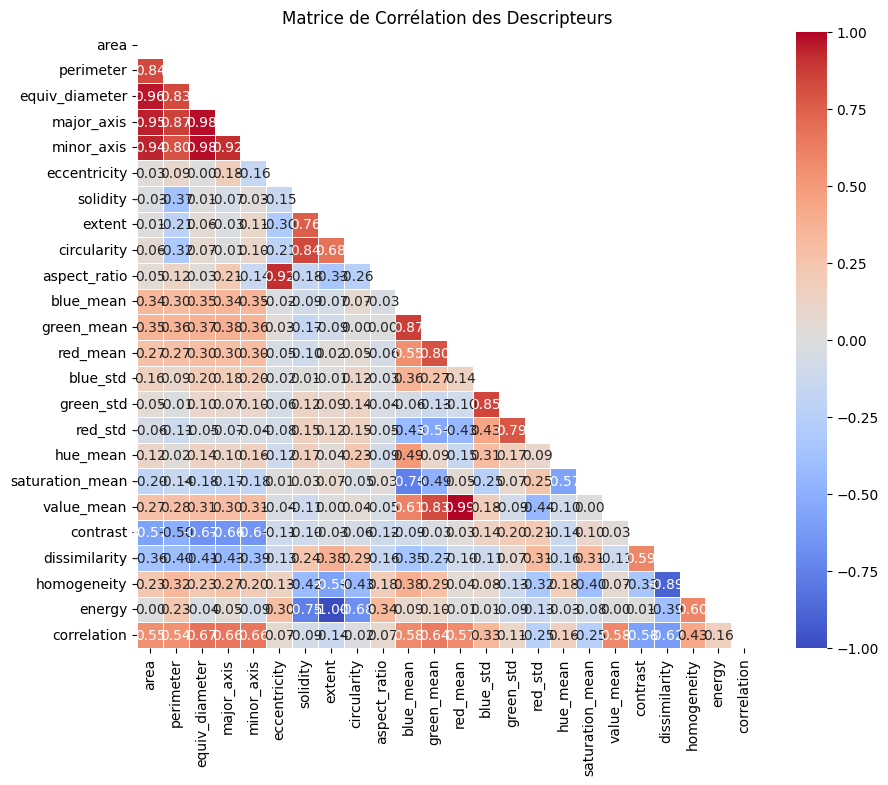

In [8]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

# --- Définition des variables ---
# X : Les données d'entrée
X = df[parametres]

# y : La variable cible 
y = df['melanoma']

# 1. Calcul de la matrice de corrélation (Pearson par défaut)
corr_matrix = X.corr()

# 2. Affichage graphique (Heatmap)
plt.figure(figsize=(10, 8)) # Taille de l'image

# Création du masque pour cacher le triangle supérieur (optionnel, mais plus lisible car symétrique)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, 
            mask=mask,             # Cache la partie supérieure
            annot=True,            # Affiche les chiffres dans les cases
            fmt=".2f",             # Limite à 2 décimales
            cmap='coolwarm',       # Couleurs : Rouge (+1) / Bleu (-1)
            vmin=-1, vmax=1,       # Bornes de l'échelle
            linewidths=0.5)        # Lignes blanches entre les cases

plt.title("Matrice de Corrélation des Descripteurs")
plt.show()

In [ ]:
# Liste des colonnes à SUPPRIMER (car redondantes)
to_drop = [
    'equiv_diameter', 
    'major_axis', 
    'minor_axis', 
    'perimeter',
    'value_mean',
    'aspect_ratio'
]

# Création du X nettoyé
X = X.drop(columns=to_drop)
parametres = [p for p in parametres if not(p in to_drop)]
X

,area,eccentricity,solidity,extent,circularity,blue_mean,green_mean,red_mean,blue_std,green_std,red_std,hue_mean,saturation_mean,contrast,dissimilarity,homogeneity,energy,correlation
image_id,,,,,,,,,,,,,,,,,,
0,364956.0,0.757181,0.968834,0.731926,0.685324,84.051231,78.636808,86.632871,42.775089,39.249347,36.083584,126.687488,38.498383,86.414011,1.838619,0.569146,0.266909,0.981932
1,53432.0,0.436456,0.927011,0.749923,0.587657,41.744479,52.943311,78.426580,20.450732,25.450673,31.941630,9.675887,118.886473,122.054822,2.603752,0.537069,0.244545,0.948470
2,237402.0,0.597147,0.915687,0.642384,0.508980,111.128415,107.868072,129.650357,37.677753,28.553130,17.352244,82.471378,58.701068,103.721010,1.799899,0.625267,0.355428,0.984986
3,260712.0,0.433660,0.955924,0.707612,0.684563,70.027985,95.549396,134.642744,31.142222,34.768891,34.925572,11.521806,125.914062,119.701065,2.204690,0.559396,0.290196,0.980469
4,269484.0,0.666933,0.986359,0.757791,0.834540,154.028681,127.536826,187.453682,38.183792,34.145424,30.190771,160.460996,83.476900,63.535053,2.144372,0.541509,0.240711,0.993242
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
511,369118.0,0.725531,0.866694,0.612461,0.359049,89.736802,99.983474,177.669130,23.492838,22.301519,17.348241,6.906355,127.871309,92.028408,1.480070,0.675967,0.385969,0.987865
513,193598.0,0.554615,0.951758,0.743284,0.760741,108.357767,139.896187,192.866502,39.821356,27.396092,10.643185,11.052965,114.079365,140.905755,1.905862,0.601861,0.255371,0.985375
516,273920.0,0.851266,0.920656,0.569705,0.602664,120.385711,151.956049,209.099865,36.735502,32.420060,24.591338,10.633539,110.914559,139.275955,2.229374,0.613182,0.428351,0.990364


In [ ]:
# 1. Calcul des statistiques textuelles
counts = y.value_counts()
percentages = y.value_counts(normalize=True) * 100

print("--- Répartition des Classes ---")
print(f"Classe 0 (Bénin ?) : {counts[0]} images ({percentages[0]:.1f}%)")
print(f"Classe 1 (Malin ?) : {counts[1]} images ({percentages[1]:.1f}%)")

# Les deux classes sont bien équilibrées

--- Répartition des Classes ---
Classe 0 (Bénin ?) : 100 images (50.0%)
Classe 1 (Malin ?) : 100 images (50.0%)


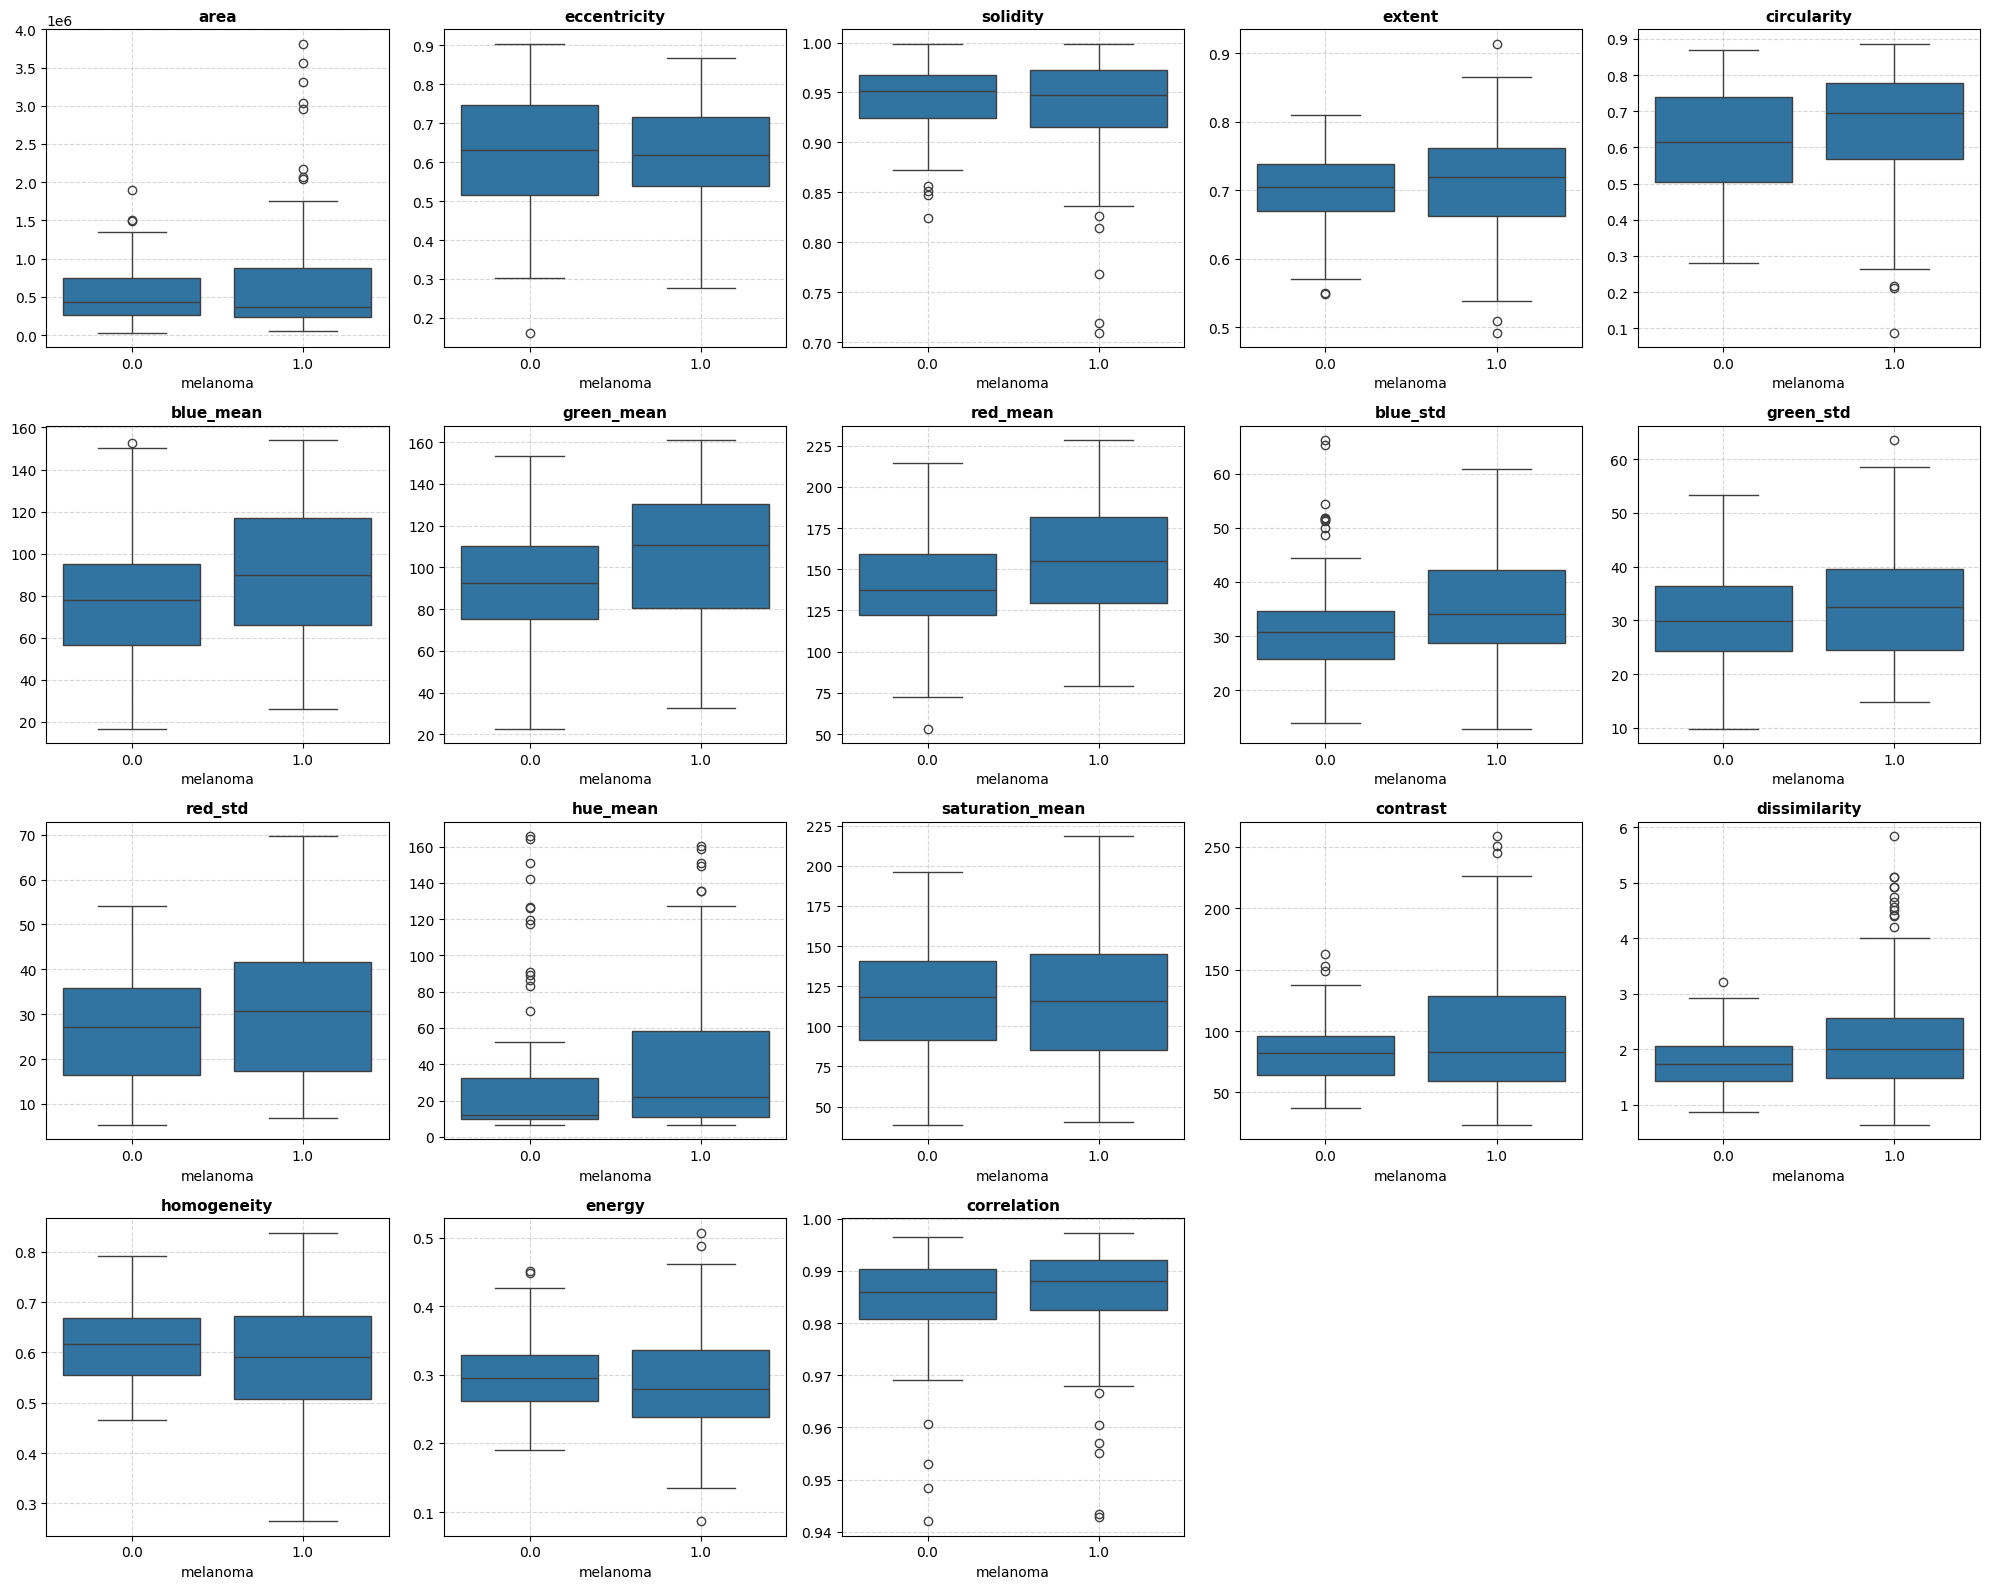

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np

# 1. Configuration de la grille
n_features = X.shape[1]
n_cols = 5
n_rows = math.ceil(n_features / n_cols) # Arrondi au supérieur (ex: 12 features / 5 = 3 lignes)

# 2. Création de la figure dynamique
# figsize=(Largeur, Hauteur) : On adapte la hauteur au nombre de lignes
plt.figure(figsize=(20, 4 * n_rows)) 

# 3. Boucle sur chaque colonne de X
for i, col_name in enumerate(X.columns):
    # Positionnement du subplot (i+1 car matplotlib commence à 1)
    plt.subplot(n_rows, n_cols, i + 1)
    
    # --- OPTION A : Distribution globale (Juste la colonne) ---
    # sns.boxplot(y=X[col_name], color='skyblue')
    
    # --- OPTION B : Distribution séparée par classe (Recommandé !) ---
    sns.boxplot(x=y, y=X[col_name]) 
    
    plt.title(col_name, fontsize=11, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.ylabel("") # On enlève le label Y pour alléger visuellement

# 4. Ajustement final pour éviter que les titres ne se chevauchent
plt.tight_layout()
plt.show()

Le constat principal est le fort chevauchement entre les deux classes. Aucun paramètre ne permet, à lui seul, de tracer une ligne parfaite pour séparer les deux groupes. C'est pour cela qu'un modèle multivarié est nécessaire. Les descripteurs de texture (Dissimilarité) et d'intensité de couleur semblent être les plus prometteurs pour distinguer les classes (classe 1 est plus élevée), tandis que les critères géométriques seuls sont moins fiables à cause de la forte variance.

## 2. Modélisation

### 2.1 Régréssion logistique

--- Démarrage de la Validation Croisée (5 folds) ---
Scores par pli : [0.8   0.8   0.65  0.75  0.825]
Accuracy Moyenne : 0.765
Écart-type : 0.062

--- Rapport de Classification (Global CV) ---
              precision    recall  f1-score   support

         0.0       0.75      0.80      0.77       100
         1.0       0.78      0.73      0.76       100

    accuracy                           0.77       200
   macro avg       0.77      0.77      0.76       200
weighted avg       0.77      0.77      0.76       200


--- Matrice de Confusion (Global CV) ---
[[80 20]
 [27 73]]


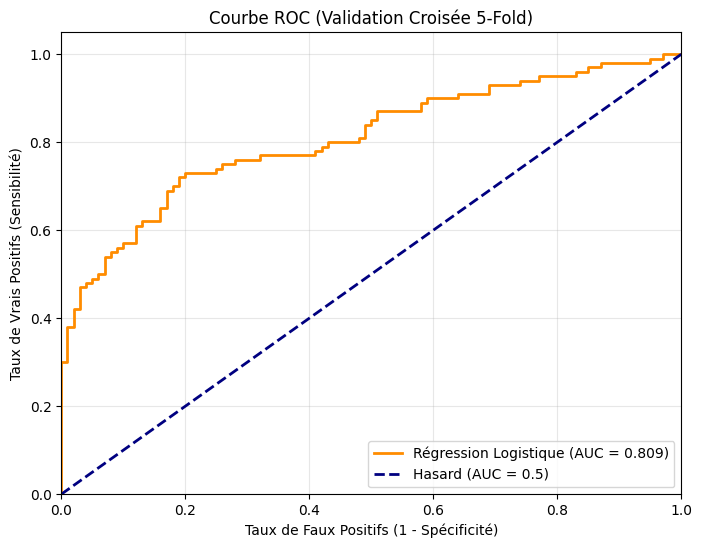

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# --- Configuration de la Validation Croisée ---

# 1. Création du Pipeline (Normalisation + Modèle)
# Le pipeline assure que le scaler est ré-ajusté pour chaque pli indépendamment
pipeline = make_pipeline(StandardScaler(), LogisticRegression(random_state=42))

# 2. Définition de la stratégie de découpage (5 plis)
# StratifiedKFold préserve le pourcentage de mélanomes dans chaque pli
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- Exécution ---

print("--- Démarrage de la Validation Croisée (5 folds) ---")

# 3. Calcul des scores d'accuracy pour chaque pli
scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')

# Affichage des statistiques de variance
print(f"Scores par pli : {np.round(scores, 3)}")
print(f"Accuracy Moyenne : {scores.mean():.3f}")
print(f"Écart-type : {scores.std():.3f}")

# --- Génération des rapports détaillés (Matrice de Confusion) ---
# Pour avoir une matrice de confusion globale issue de la validation croisée,
# on utilise cross_val_predict qui concatène les prédictions de chaque pli de test.

y_pred_cv = cross_val_predict(pipeline, X, y, cv=cv)

print("\n--- Rapport de Classification (Global CV) ---")
print(classification_report(y, y_pred_cv))

print("\n--- Matrice de Confusion (Global CV) ---")
print(confusion_matrix(y, y_pred_cv))

# --- Courbe ROC et AUC ---

# 1. Récupération des probabilités (au lieu des classes 0/1)
# method='predict_proba' est CRUCIAL ici. On prend la colonne [:, 1] (Probabilité d'être Malin)
y_probs = cross_val_predict(pipeline, X, y, cv=cv, method='predict_proba')[:, 1]

# 2. Calcul des métriques ROC (Faux Positifs vs Vrais Positifs)
fpr, tpr, thresholds = roc_curve(y, y_probs)
roc_auc = auc(fpr, tpr)

# 3. Tracé du graphique
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Régression Logistique (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Hasard (AUC = 0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (1 - Spécificité)')
plt.ylabel('Taux de Vrais Positifs (Sensibilité)')
plt.title('Courbe ROC (Validation Croisée 5-Fold)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

La Régression Logistique s'impose comme un modèle de référence robuste pour ce jeu de données. Avec une accuracy moyenne de 76.5% et surtout une AUC de 0.809, le modèle démontre une capacité discriminante satisfaisante. Bien que le modèle reste linéaire, il parvient à généraliser correctement malgré la taille réduite de l'échantillon (200 images), comme en témoigne l'équilibre entre la Précision (0.78) et le Rappel (0.73) pour la classe maligne.

### 2.2 Forêt aléatoire

--- Démarrage de la Random Forest (20-Fold) ---
Scores par pli : [0.9 0.5 0.9 0.7 0.7 0.8 0.8 0.8 0.7 0.8 0.7 0.5 0.6 0.6 0.6 0.7 0.7 0.7
 0.6 0.9]
Accuracy Moyenne : 0.710 (+/- 0.236)

--- Rapport de Classification ---
              precision    recall  f1-score   support

         0.0       0.69      0.75      0.72       100
         1.0       0.73      0.67      0.70       100

    accuracy                           0.71       200
   macro avg       0.71      0.71      0.71       200
weighted avg       0.71      0.71      0.71       200



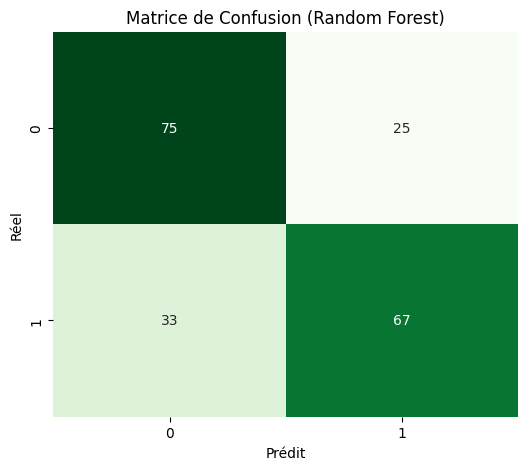

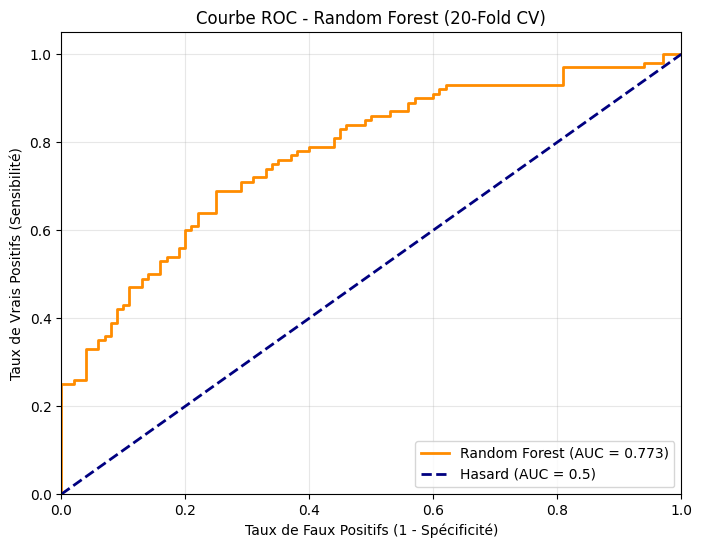

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc

# --- Configuration du Modèle et de la Validation ---

rf_model = RandomForestClassifier(n_estimators=100, 
                                  max_depth = 4,
                                  min_samples_leaf = 1,
                                  random_state=42)

cv = StratifiedKFold(n_splits=20, shuffle=True, random_state=42)

# --- Exécution de la Validation Croisée ---

print("--- Démarrage de la Random Forest (20-Fold) ---")

# Calcul des scores (Accuracy)
scores = cross_val_score(rf_model, X, y, cv=cv, scoring='accuracy')

print(f"Scores par pli : {np.round(scores, 3)}")
print(f"Accuracy Moyenne : {scores.mean():.3f} (+/- {scores.std() * 2:.3f})")

# Récupération des prédictions globales pour la matrice de confusion
y_pred_cv = cross_val_predict(rf_model, X, y, cv=cv)


# ---  Évaluation Graphique (Matrice de Confusion) ---

print("\n--- Rapport de Classification ---")
print(classification_report(y, y_pred_cv))

# Matrice de confusion visuelle
plt.figure(figsize=(6, 5))
conf_mat = confusion_matrix(y, y_pred_cv)
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Matrice de Confusion (Random Forest)')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.show()

# --- Courbe ROC et AUC ---

# 1. Récupération des PROBABILITÉS (Indispensable pour la courbe ROC)
# method='predict_proba' retourne un tableau de forme (n_samples, 2)
y_probs = cross_val_predict(rf_model, X, y, cv=cv, method='predict_proba')

# On ne garde que la probabilité de la classe positive (Mélanome / 1)
y_probs_positive = y_probs[:, 1]

# 2. Calcul des métriques
fpr, tpr, thresholds = roc_curve(y, y_probs_positive)
roc_auc = auc(fpr, tpr)

# 3. Tracé de la Courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Random Forest (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Hasard (AUC = 0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (1 - Spécificité)')
plt.ylabel('Taux de Vrais Positifs (Sensibilité)')
plt.title('Courbe ROC - Random Forest (20-Fold CV)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

### Analyse des Résultats : Forêt Aléatoire (Random Forest)

**1. Justification des Hyperparamètres (Contrôle du Sur-apprentissage)**
Pour ce modèle, une approche conservatrice a été privilégiée afin de limiter les risques de sur-apprentissage inhérents aux petits jeux de données (200 images).

* **`n_estimators = 100` :** Un nombre standard d'arbres pour assurer une moyenne statistique stable.
* **`max_depth = 4` :** Nous avons volontairement bridé la profondeur des arbres à 4 niveaux. Ce choix vise à forcer le modèle à ne regarder que les caractéristiques les plus généralistes. 

**2. Performance Globale et Comparaison**
Le modèle obtient une **Accuracy moyenne de 71.0%** et une **AUC de 0.773**.

* Ces résultats sont en retrait par rapport à la Régression Logistique (Acc: 76.5%, AUC: 0.809).
* Cela suggère que sur ce dataset spécifique, la séparation linéaire (Régression Logistique) est plus efficace qu'une séparation non-linéaire mais trop contrainte (`max_depth=4`). La Forêt Aléatoire n'a pas pu déployer toute sa puissance de modélisation complexe.

**3. Analyse de la Stabilité (Validation Croisée à 20 Plis)**
Le choix d'un **K=20** (20-Fold) sur 200 images implique que chaque test ne porte que sur **10 images**.

* Cette fragmentation explique la très forte variance observée (**+/- 23.6%**).
* On observe des scores extrêmes allant de **0.50** (performance du hasard) sur certains plis à **0.90** sur d'autres. Cela démontre une instabilité statistique : le modèle est très sensible à la "chance" du tirage des images de test.

**4. Capacité de Détection (Matrice de Confusion)**
Le modèle présente un léger déséquilibre en faveur de la classe bénigne :

* **Spécificité (Bénins détectés) :** 74%
* **Sensibilité (Mélanomes détectés) :** 68%


--- Importance des Descripteurs ---
            Feature  Importance
14    dissimilarity    0.109379
13         contrast    0.085329
6        green_mean    0.084426
15      homogeneity    0.080851
8          blue_std    0.070583
10          red_std    0.060809
5         blue_mean    0.058642
17      correlation    0.056899
7          red_mean    0.054174
16           energy    0.053614
0              area    0.049175
3            extent    0.048726
11         hue_mean    0.047379
12  saturation_mean    0.032417
4       circularity    0.030381
9         green_std    0.029134
2          solidity    0.027410
1      eccentricity    0.020672


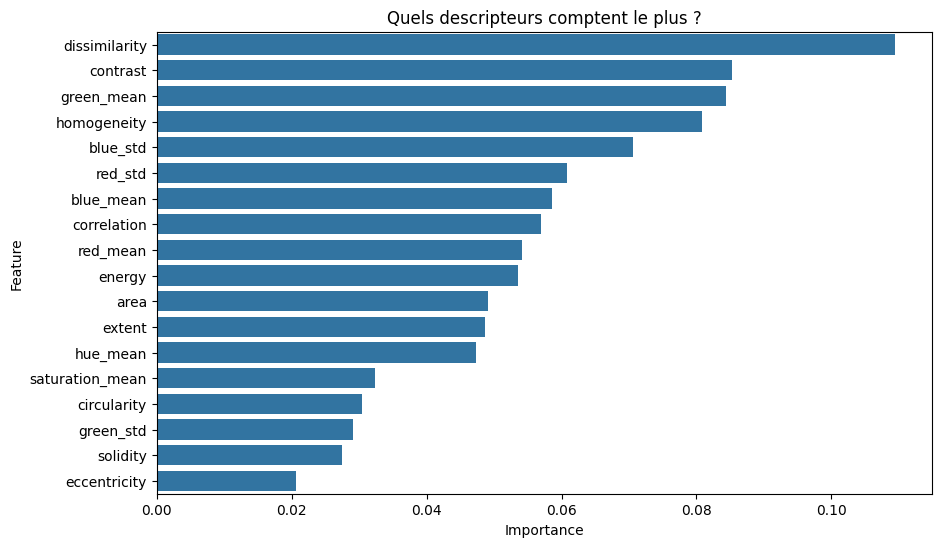

In [38]:
# ---  Feature Importance ---

# Pour extraire l'importance, on ré-entraîne le modèle sur TOUT le dataset une fois
rf_model.fit(X, y)

importances = pd.DataFrame({
    'Feature': parametres,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n--- Importance des Descripteurs ---")
print(importances)

# Visualisation des importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importances)
plt.title('Quels descripteurs comptent le plus ?')
plt.show()

L'analyse révèle une nette prédominance des descripteurs de Texture (GLCM) sur la géométrie.
(Dissimilarité (10.9%) et le Contraste (8.5%) vs l'aire (4.9%) et la forme (Solidity, 2.7%))

### 1.3 SVM

Optimisation du SVM en cours...
Fitting 10 folds for each of 24 candidates, totalling 240 fits

Meilleurs paramètres : {'svc__C': 10, 'svc__kernel': 'linear'}
Meilleure Accuracy (CV) : 0.760

--- Rapport de Classification ---
              precision    recall  f1-score   support

         0.0       0.72      0.84      0.78       100
         1.0       0.81      0.68      0.74       100

    accuracy                           0.76       200
   macro avg       0.77      0.76      0.76       200
weighted avg       0.77      0.76      0.76       200



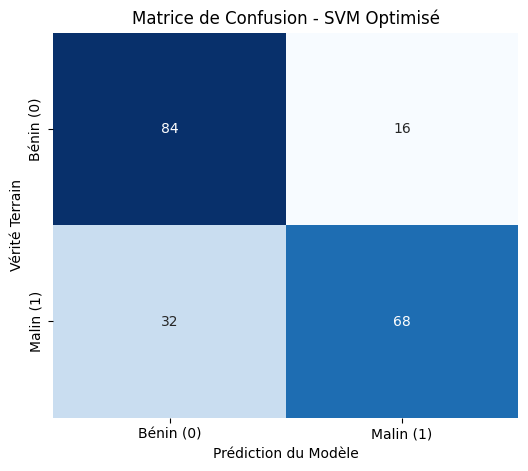

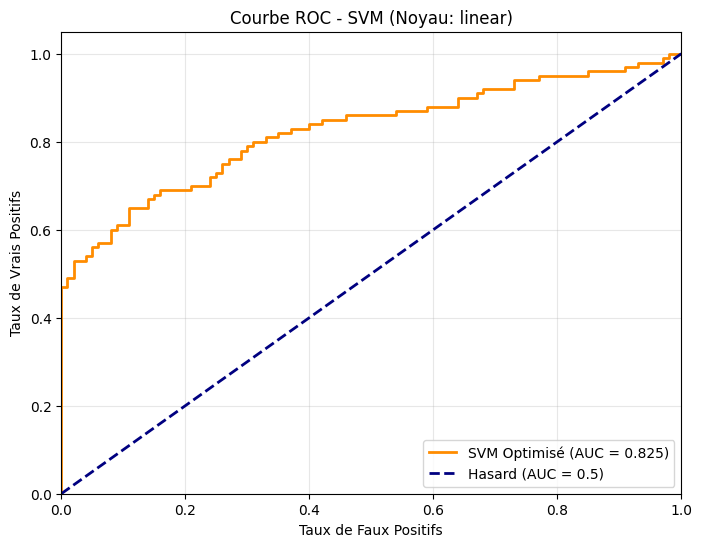

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# --- 1. Configuration et Entraînement (GridSearch) ---

# Pipeline avec probability=True (nécessaire pour ROC)
svm_pipeline = make_pipeline(StandardScaler(), SVC(probability=True, class_weight='balanced'))

param_grid = [
    {'svc__kernel': ['linear'], 'svc__C': [0.1, 1, 10, 100]},
    {'svc__kernel': ['rbf'], 
     'svc__C': [0.1, 1, 10, 100], 
     'svc__gamma': [0.001, 0.01, 0.1, 1, 'scale']}
]

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

print("Optimisation du SVM en cours...")
grid_svm = GridSearchCV(svm_pipeline, param_grid, cv=cv, scoring='accuracy', verbose=1, n_jobs=-1)
grid_svm.fit(X, y)

best_svm = grid_svm.best_estimator_

print(f"\nMeilleurs paramètres : {grid_svm.best_params_}")
print(f"Meilleure Accuracy (CV) : {grid_svm.best_score_:.3f}")


# --- 2. Génération des Prédictions via Validation Croisée ---
# Cette étape est cruciale : on prédit tout le dataset sans tricher (overfitting)
# grâce à cross_val_predict qui utilise les plis de test.

# A. Prédictions "Dures" (0 ou 1) -> Pour la Matrice et le Rapport
y_pred = cross_val_predict(best_svm, X, y, cv=cv)

# B. Prédictions "Probabilistes" (0.0 à 1.0) -> Pour la Courbe ROC
y_probs = cross_val_predict(best_svm, X, y, cv=cv, method='predict_proba')[:, 1]


# --- 3. Affichage des Résultats ---

# A. Rapport de Classification
print("\n--- Rapport de Classification ---")
print(classification_report(y, y_pred))

# B. Matrice de Confusion
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Bénin (0)', 'Malin (1)'],
            yticklabels=['Bénin (0)', 'Malin (1)'])
plt.title('Matrice de Confusion - SVM Optimisé')
plt.ylabel('Vérité Terrain')
plt.xlabel('Prédiction du Modèle')
plt.show()

# C. Courbe ROC
fpr, tpr, _ = roc_curve(y, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'SVM Optimisé (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Hasard (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs')
plt.title(f'Courbe ROC - SVM (Noyau: {grid_svm.best_params_["svc__kernel"]})')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

### Analyse des Résultats : SVM Optimisé

**1. Configuration et Performance Globale**
L'optimisation des hyperparamètres a favorisé un **noyau linéaire** (`C=10`), surpassant le noyau RBF. Cela indique que les descripteurs extraits (géométrie et texture) permettent une séparation linéaire efficace des classes. Le modèle atteint une **Accuracy de 76%** (équivalente à la Régression Logistique) mais se distingue par une **AUC de 0.825**, confirmant sa supériorité mathématique pour classer les probabilités.

**2. Analyse Clinique (Matrice de Confusion)**
Le comportement du modèle est caractérisé par une **haute précision mais une sensibilité modérée** :

* **Fiabilité (Précision : 81%) :** Le modèle génère peu de fausses alertes (seulement 16 Faux Positifs), ce qui le rend très crédible lorsqu'il prédit une malignité.
* **Risque (Rappel : 0.68) :** C'est la limite principale de cette configuration. Avec **32 Faux Négatifs**, le modèle manque encore 32% des mélanomes.

**Conclusion**
Le SVM linéaire est le modèle le plus robuste statistiquement (meilleure AUC). Cependant, pour une application diagnostique sécurisée, il serait nécessaire d'abaisser son seuil de décision pour récupérer les mélanomes manqués, au prix d'une légère baisse de précision.